# プロジェクト概要
- 不動産データのK近傍回帰を行いました
- ワインデータのk近傍分類を行いました
- pandas、matplotlib、numpy、sklearnライブラリを使用しました

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

# 1. K近傍回帰

### 分析データの読み込みと確認

In [4]:
mydata = pd.read_csv("Real_estate_valuation_data_set.csv",delimiter=",")
mydata.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


### 相関係数の確認と説明変数の選定

In [5]:
mydata.corr()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
No,1.000000,-0.048658,-0.032808,-0.013573,-0.012699,-0.010110,-0.011059,-0.028587
X1 transaction date,-0.048658,1.000000,0.017549,0.060880,0.009635,0.035058,-0.041082,0.087491
X2 house age,-0.032808,0.017549,1.000000,0.025622,0.049593,0.054420,-0.048520,-0.210567
X3 distance to the nearest MRT station,-0.013573,0.060880,0.025622,1.000000,-0.602519,-0.591067,-0.806317,-0.673613
X4 number of convenience stores,-0.012699,0.009635,0.049593,-0.602519,1.000000,0.444143,0.449099,0.571005
X5 latitude,-0.010110,0.035058,0.054420,-0.591067,0.444143,1.000000,0.412924,0.546307
X6 longitude,-0.011059,-0.041082,-0.048520,-0.806317,0.449099,0.412924,1.000000,0.523287
Y house price of unit area,-0.028587,0.087491,-0.210567,-0.673613,0.571005,0.546307,0.523287,1.000000


### 説明変数の可視化

In [6]:
var1 = "X3 distance to the nearest MRT station"
var2 = "X6 longitude"
var3 = "X5 latitude"

MRT = mydata[var1] 
longitude = mydata[var2]
latitude = mydata[var3]
price = mydata["Y house price of unit area"]

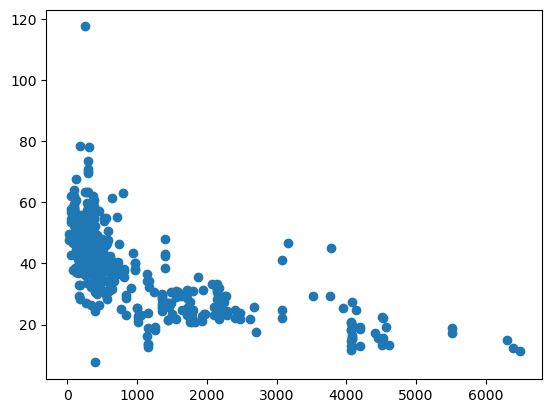

In [9]:
plt.scatter(MRT,price)

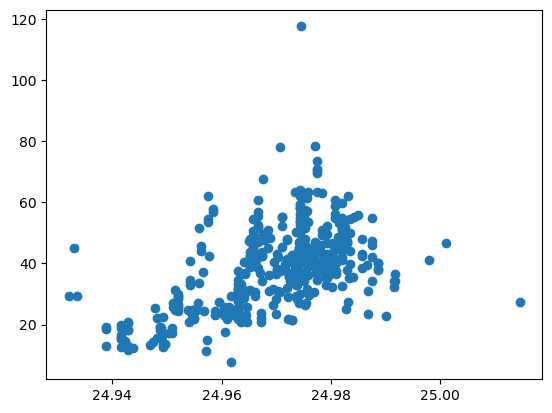

In [10]:
plt.scatter(latitude,price)

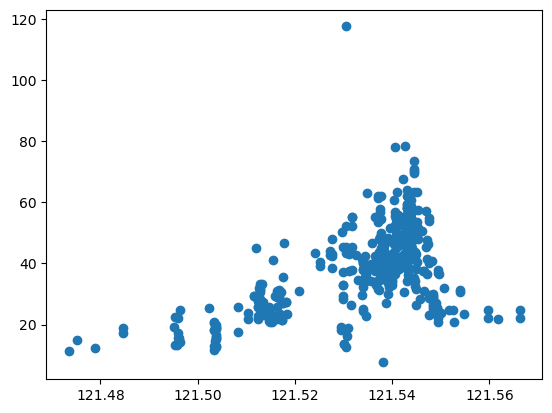

In [11]:
plt.scatter(longitude,price)

### K近傍回帰の実行と可視化

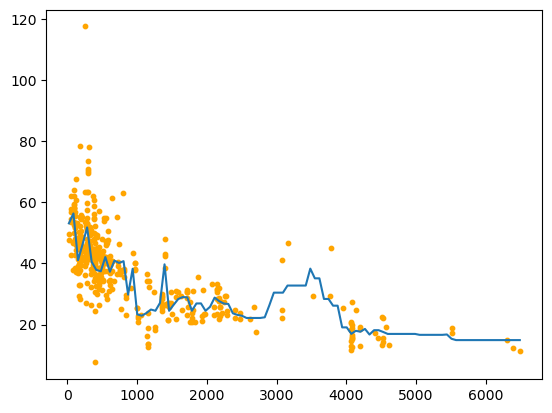

In [26]:
#説明変数1
X = mydata[[var1]]
y = price
K = 5
model = KNeighborsRegressor(n_neighbors=K)
model.fit(X,y)
x_line = np.linspace(MRT.min(), MRT.max(), 100)
x_line = x_line.reshape(-1,1)
y_line = []
y_line = model.predict(x_line)
plt.scatter(MRT, price, color="orange", s=10)
plt.plot(x_line, y_line)

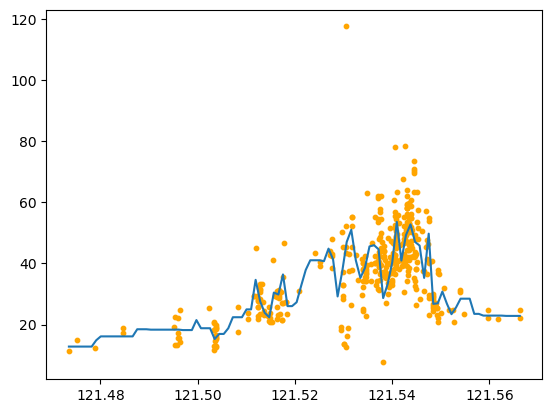

In [27]:
#説明変数2
X = mydata[[var2]]
y = price
K = 3
model = KNeighborsRegressor(n_neighbors=K)
model.fit(X,y)
x_line = np.linspace(longitude.min(), longitude.max(), 100)
x_line = x_line.reshape(-1,1)
y_line = []
y_line = model.predict(x_line)
plt.scatter(longitude, price, color="orange", s=10)
plt.plot(x_line, y_line)

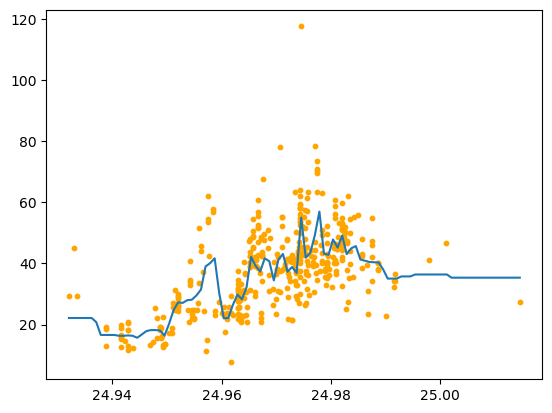

In [28]:
#説明変数3
X = mydata[[var3]]
y = price
K = 10
model = KNeighborsRegressor(n_neighbors=K)
model.fit(X,y)
x_line = np.linspace(latitude.min(), latitude.max(), 100)
x_line = x_line.reshape(-1,1)
y_line = []
# for i in range(len(x_line)):
y_line = model.predict(x_line)
plt.scatter(latitude, price, color="orange", s=10)
plt.plot(x_line, y_line)

# 2. K近傍分類

### データの読み込み

In [30]:
mydata2 = pd.read_csv("wine.csv")
mydata2

,class,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


### データの分類と可視化

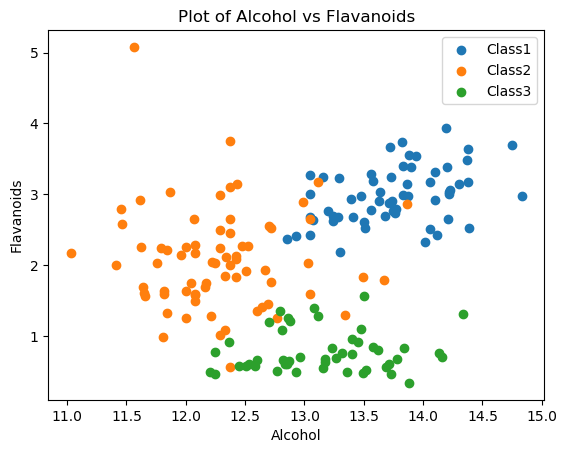

In [31]:
classes = {1:'Class1', 2:'Class2', 3:'Class3'}
y = mydata2["class"]
var1 = "Alcohol"
var2 = "Flavanoids"

#Get the complete column corresponding to var1 and var 2
x1_all = mydata2[var1]
x2_all = mydata2[var2]

#Keep only values corresponding to Setosa flower
x1_y0 = x1_all[y==1]
x2_y0 = x2_all[y==1]

#Keep only values corresponding to Virginica flower
x1_y1 = x1_all[y==2]
x2_y1 = x2_all[y==2]

#
x1_y2 = x1_all[y==3]
x2_y2 = x2_all[y==3]


plt.scatter(x1_y0,x2_y0)
plt.scatter(x1_y1,x2_y1)
plt.scatter(x1_y2,x2_y2)
plt.legend([classes[1], classes[2], classes[3]])
plt.xlabel(var1)
plt.ylabel(var2)
plt.title('Plot of ' + var1 + ' vs ' + var2)
plt.show()

### K近傍分類の実行と正解率の計算

In [32]:
X = mydata2[[var1,var2]]
K = 2
model = KNeighborsClassifier(n_neighbors=K)
model.fit(X,y)
ypred = model.predict(X)

In [37]:
def accuracy(acct, pred):
    correct = 0
    wrong = 0
    for i in range(len(acct)):
        if acct[i]==pred[i]:
            correct+=1
        else:
            wrong+=1
    return correct/(correct+wrong)
print("正解率:",accuracy(y, ypred))

正解率: 0.949438202247191
